# Row Reduction and LU Decomposition

Notebook ini merangkum Chapter 10 dari *Practical Linear Algebra for Data Science*. Chapter ini membahas sistem persamaan, row reduction, Gaussian elimination, Gauss-Jordan elimination, matrix inverse melalui RREF, serta LU decomposition.

Pembahasan dibuat ringkas seperti style Chapter 3: fokus pada isi chapter, rumus yang relevan, kode inti, dan kesimpulan.

## Tujuan Pembelajaran

- Memahami cara mengubah system of equations menjadi matrix equation.
- Memahami aturan manipulasi matrix equation.
- Menjelaskan row reduction dan echelon form.
- Memahami Gaussian elimination dan back substitution.
- Memahami Gauss-Jordan elimination dan reduced row echelon form.
- Menjelaskan matrix inverse melalui Gauss-Jordan elimination.
- Memahami LU decomposition sebagai dekomposisi lower dan upper triangular matrix.
- Memahami peran permutation matrix dalam row swaps.
- Mengetahui hubungan LU decomposition dengan determinant dan matrix inverse.

## Ringkasan Chapter

Chapter ini memperkenalkan LU decomposition, tetapi sebelum masuk ke LU, chapter menjelaskan fondasi yang dibutuhkan terlebih dahulu: systems of equations, row reduction, Gaussian elimination, dan echelon matrices.

Sistem persamaan dapat ditulis sebagai matrix equation dalam bentuk $Ax=b$. Bentuk ini membuat sistem persamaan lebih ringkas dan memungkinkan penyelesaian menggunakan operasi linear algebra. Namun, saat bekerja dengan matrix equation, urutan perkalian harus diperhatikan karena matrix multiplication tidak komutatif.

Row reduction adalah proses mengubah dense matrix menjadi upper-triangular matrix menggunakan manipulasi baris, seperti scalar multiplication dan row addition. Teknik ini menjadi dasar Gaussian elimination, yaitu metode menyelesaikan sistem persamaan tanpa menghitung inverse secara langsung.

Chapter juga membahas Gauss-Jordan elimination, yaitu kelanjutan dari Gaussian elimination sampai matrix berada dalam reduced row echelon form (RREF). RREF dapat langsung menampilkan solusi sistem persamaan dan juga dapat digunakan untuk menghitung matrix inverse.

Bagian akhir chapter membahas LU decomposition. LU decomposition memecah matrix menjadi lower-triangular matrix dan upper-triangular matrix. Jika dibutuhkan row swaps, permutation matrix digunakan. Dalam SciPy, LU decomposition direpresentasikan dengan urutan $A=PLU$.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| Systems of Equations | Sistem persamaan dapat dimanipulasi selama operasi diterapkan pada kedua sisi. |
| Converting Equations into Matrices | Sistem persamaan dapat ditulis sebagai $Ax=b$. |
| Working with Matrix Equations | Matrix multiplication tidak komutatif sehingga urutan perkalian penting. |
| Row Reduction | Dense matrix diubah menjadi upper-triangular matrix. |
| Gaussian Elimination | Menyelesaikan sistem persamaan melalui augmented matrix, row reduction, dan back substitution. |
| Gauss-Jordan Elimination | Row reduction dilanjutkan sampai RREF sehingga solusi langsung terlihat. |
| Matrix Inverse via RREF | Inverse dapat dihitung dengan RREF pada augmented matrix $[A\ I]$. |
| LU Decomposition | Matrix dipecah menjadi lower dan upper triangular matrix. |
| Permutation Matrix | Digunakan untuk row swaps dalam LU decomposition. |

## Persiapan Library

In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

try:
    import scipy.linalg
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

try:
    import sympy as sym
    SYMPY_AVAILABLE = True
except Exception:
    SYMPY_AVAILABLE = False

np.random.seed(2024)

## Systems of Equations

Sistem persamaan terdiri dari beberapa equation yang harus dipertimbangkan secara bersamaan. Satu equation saja biasanya tidak cukup untuk menentukan nilai beberapa variable.

Contoh dari chapter:

$$
x = 4-y
$$

$$
y = \frac{x}{2}+2
$$

Kedua equation tersebut harus diselesaikan bersama untuk mendapatkan nilai:

$$
x=\frac{4}{3},\quad y=\frac{8}{3}
$$

Ide pentingnya: equation dapat dikalikan scalar dan ditambahkan atau dikurangkan dengan equation lain selama solusi akhirnya tetap sama.

## Converting Equations into Matrices

Sistem persamaan dapat diubah menjadi matrix equation dengan dua langkah:

1. Susun variable di sisi kiri dan constant di sisi kanan.
2. Pisahkan coefficients ke matrix, variable ke vector, dan constants ke vector.

Contoh:

$$
x+y=4
$$

$$
-\frac{1}{2}x+y=2
$$

ditulis sebagai:

$$
\begin{bmatrix}
1 & 1 \\
-\frac{1}{2} & 1
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
=
\begin{bmatrix}
4 \\
2
\end{bmatrix}
$$

Secara umum:

$$
Ax=b
$$

Keterangan:

- $A$ = coefficient matrix
- $x$ = vector variable yang dicari
- $b$ = vector constants

In [15]:
A = np.array([
    [1, 1],
    [-1/2, 1]
], dtype=float)

b = np.array([4, 2], dtype=float)

x = np.linalg.solve(A, b)

print("Solution [x, y]:", x)
print("Check A @ x:", A @ x)

Solution [x, y]: [1.33333333 2.66666667]
Check A @ x: [4. 2.]


## Working with Matrix Equations

Matrix equation dapat dimanipulasi seperti persamaan biasa, tetapi aturan matrix multiplication harus diperhatikan. Operasi harus dilakukan pada kedua sisi dengan cara yang konsisten.

Contoh yang valid:

$$
AX=B
$$

$$
CAX=CB
$$

Karena $C$ sama-sama melakukan premultiply pada kedua sisi.

Contoh yang tidak valid secara umum:

$$
AXC=CB
$$

karena $C$ postmultiply di sisi kiri tetapi premultiply di sisi kanan. Masalah ini muncul karena matrix multiplication tidak komutatif.

In [16]:
A = np.random.randn(4, 4)
B = np.random.randn(4, 4)

X1 = np.linalg.inv(A) @ B
X2 = B @ np.linalg.inv(A)

res1 = A @ X1 - B
res2 = A @ X2 - B

print("Residual using X1 = inv(A) @ B:")
print(np.round(res1, 4))

print("\nResidual using X2 = B @ inv(A):")
print(np.round(res2, 4))

Residual using X1 = inv(A) @ B:
[[ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]
 [-0. -0. -0.  0.]
 [-0.  0.  0.  0.]]

Residual using X2 = B @ inv(A):
[[ 3.1739 -0.0582 -3.6117  3.284 ]
 [ 1.8301  1.0363  1.2815  6.6835]
 [ 0.8038  0.2139 -1.0637  2.4812]
 [-1.1879 -0.7906  0.5467 -3.1466]]


## Row Reduction

Row reduction adalah proses mengubah matrix padat menjadi upper-triangular matrix melalui operasi baris. Operasi yang digunakan adalah scalar multiplication dan row addition.

Tujuan utama row reduction:

$$
\text{dense matrix} \rightarrow \text{upper-triangular matrix}
$$

Contoh sederhana:

$$
\begin{bmatrix}
2 & 3 \\
-2 & 2
\end{bmatrix}
\xrightarrow{R_1+R_2}
\begin{bmatrix}
2 & 3 \\
0 & 5
\end{bmatrix}
$$

Matrix hasil row reduction ini disebut echelon form.

## Echelon Form

Sebuah matrix berada dalam echelon form jika:

1. Pivot di setiap row berada di kanan pivot row di atasnya.
2. Row yang seluruh elemennya nol berada di bawah row yang memiliki elemen nonzero.

Pivot adalah angka nonzero paling kiri dalam suatu row.

Echelon form tidak unik. Satu matrix bisa memiliki banyak bentuk echelon yang berbeda, tergantung urutan manipulasi baris.

In [17]:
A = np.array([
    [2, 3],
    [-2, 2]
], dtype=float)

# Row 2 = Row 1 + Row 2
U = A.copy()
U[1, :] = U[0, :] + U[1, :]

print("Original matrix:")
print(A)

print("\nEchelon form:")
print(U)

Original matrix:
[[ 2.  3.]
 [-2.  2.]]

Echelon form:
[[2. 3.]
 [0. 5.]]


## Row Reduction sebagai Matrix Transformation

Row reduction dapat ditulis sebagai matrix multiplication. Pada contoh sebelumnya, transformasi row reduction dapat ditulis sebagai:

$$
L^{-1}A=U
$$

Keterangan:

- $A$ = matrix awal
- $U$ = upper-triangular matrix hasil row reduction
- $L^{-1}$ = matrix transformasi yang menyimpan manipulasi baris

Ide ini menjadi dasar menuju LU decomposition.

In [18]:
A = np.array([
    [2, 3],
    [-2, 2]
], dtype=float)

Linv = np.array([
    [1, 0],
    [1, 1]
], dtype=float)

U = Linv @ A

print(U)

[[2. 3.]
 [0. 5.]]


## Gaussian Elimination

Gaussian elimination adalah metode untuk menyelesaikan sistem persamaan tanpa menghitung inverse matrix secara langsung.

Langkahnya:

1. Ubah sistem persamaan menjadi matrix equation.
2. Buat augmented matrix dengan menambahkan vector constants.
3. Lakukan row reduction sampai echelon form.
4. Gunakan back substitution untuk mencari nilai variable.

Contoh augmented matrix:

$$
\begin{bmatrix}
1 & 1 & 4 \\
-\frac{1}{2} & 1 & 2
\end{bmatrix}
$$

Setelah row reduction:

$$
\begin{bmatrix}
1 & 1 & 4 \\
0 & \frac{3}{2} & 4
\end{bmatrix}
$$

In [19]:
M = np.array([
    [1, 1, 4],
    [-1/2, 1, 2]
], dtype=float)

# R2 = 1/2 R1 + R2
M_echelon = M.copy()
M_echelon[1, :] = 0.5*M_echelon[0, :] + M_echelon[1, :]

print("Augmented matrix:")
print(M)

print("\nEchelon form:")
print(M_echelon)

# Back substitution
y = M_echelon[1, 2] / M_echelon[1, 1]
x = M_echelon[0, 2] - y

print("\nBack substitution solution:")
print("x =", x)
print("y =", y)

Augmented matrix:
[[ 1.   1.   4. ]
 [-0.5  1.   2. ]]

Echelon form:
[[1.  1.  4. ]
 [0.  1.5 4. ]]

Back substitution solution:
x = 1.3333333333333335
y = 2.6666666666666665


## Gauss-Jordan Elimination dan RREF

Gauss-Jordan elimination melanjutkan Gaussian elimination sampai setiap pivot bernilai 1 dan menjadi satu-satunya angka nonzero di column tersebut.

Hasil akhirnya disebut reduced row echelon form atau RREF.

Untuk contoh sebelumnya, RREF-nya adalah:

$$
\begin{bmatrix}
1 & 0 & \frac{4}{3} \\
0 & 1 & \frac{8}{3}
\end{bmatrix}
$$

Dengan RREF, solusi langsung terlihat tanpa back substitution:

$$
x=\frac{4}{3},\quad y=\frac{8}{3}
$$

In [20]:
M = np.array([
    [1, 1, 4],
    [-1/2, 1, 2]
], dtype=float)

if SYMPY_AVAILABLE:
    symMat = sym.Matrix(M)
    rref_matrix = symMat.rref()[0]
    print(rref_matrix)
else:
    print("SymPy tidak tersedia di environment ini.")

SymPy tidak tersedia di environment ini.


## Matrix Inverse via Gauss-Jordan Elimination

Gauss-Jordan elimination juga dapat digunakan untuk menghitung matrix inverse. Caranya adalah membuat augmented matrix berisi matrix $A$ dan identity matrix.

### Rumus RREF untuk Matrix Inverse

$$
\mathrm{rref}
\left(
\begin{bmatrix}
A & I
\end{bmatrix}
\right)
=
\begin{bmatrix}
I & A^{-1}
\end{bmatrix}
$$

Keterangan:

- $A$ = square full-rank matrix
- $I$ = identity matrix
- $A^{-1}$ = inverse matrix

Metode ini menghitung inverse tanpa determinant, tetapi tetap dapat mengalami numerical precision error jika matrix mendekati singular.

In [21]:
A = np.array([
    [2, 1],
    [1, 3]
], dtype=float)

if SYMPY_AVAILABLE:
    AI = np.hstack((A, np.eye(2)))
    rref_AI = sym.Matrix(AI).rref()[0]
    print(rref_AI)
else:
    print("SymPy tidak tersedia di environment ini.")

print("\nNumPy inverse:")
print(np.linalg.inv(A))

SymPy tidak tersedia di environment ini.

NumPy inverse:
[[ 0.6 -0.2]
 [-0.2  0.4]]


## LU Decomposition

LU decomposition memecah matrix menjadi dua triangular matrix.

### Rumus LU Decomposition

$$
A=LU
$$

Keterangan:

- $A$ = matrix asal
- $L$ = lower-triangular matrix
- $U$ = upper-triangular matrix

LU berarti “lower-upper”. Matrix $U$ berkaitan dengan hasil row reduction, sedangkan $L$ menyimpan informasi transformasi baris yang dibutuhkan untuk menghasilkan $U$.

## Contoh LU Decomposition

Chapter memberikan contoh matrix:

$$
A =
\begin{bmatrix}
2 & 2 & 4 \\
1 & 0 & 3 \\
2 & 1 & 2
\end{bmatrix}
$$

yang dapat didekomposisi menjadi:

$$
L =
\begin{bmatrix}
1 & 0 & 0 \\
\frac{1}{2} & 1 & 0 \\
1 & 1 & 1
\end{bmatrix}
$$

dan:

$$
U =
\begin{bmatrix}
2 & 2 & 4 \\
0 & -1 & 1 \\
0 & 0 & -3
\end{bmatrix}
$$

Pada SciPy, fungsi `scipy.linalg.lu()` digunakan untuk menghitung LU decomposition.

In [22]:
A = np.array([
    [2, 2, 4],
    [1, 0, 3],
    [2, 1, 2]
], dtype=float)

if SCIPY_AVAILABLE:
    P, L, U = scipy.linalg.lu(A)

    print("P:")
    print(P)

    print("\nL:")
    print(L)

    print("\nU:")
    print(U)

    print("\nReconstruction A = P @ L @ U:")
    print(P @ L @ U)
else:
    print("SciPy tidak tersedia di environment ini.")

P:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

L:
[[1.  0.  0. ]
 [0.5 1.  0. ]
 [1.  1.  1. ]]

U:
[[ 2.  2.  4.]
 [ 0. -1.  1.]
 [ 0.  0. -3.]]

Reconstruction A = P @ L @ U:
[[2. 2. 4.]
 [1. 0. 3.]
 [2. 1. 2.]]


## Visualisasi LU Decomposition

LU decomposition memecah matrix menjadi lower-triangular dan upper-triangular matrix. Visualisasi membantu melihat struktur $L$ dan $U$.

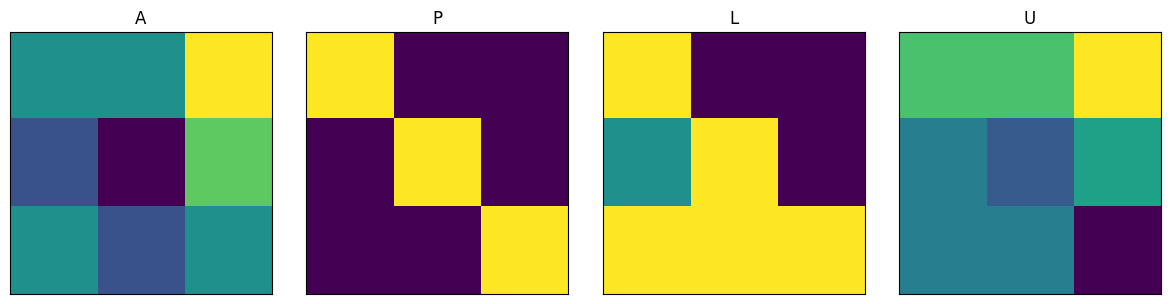

In [23]:
if SCIPY_AVAILABLE:
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))

    mats = [
        ("A", A),
        ("P", P),
        ("L", L),
        ("U", U)
    ]

    for ax, (title, mat) in zip(axes, mats):
        ax.imshow(mat)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()
else:
    print("SciPy tidak tersedia di environment ini.")

## LU Decomposition dan Row Reduction

Chapter menjelaskan bahwa row reduction dapat ditulis sebagai:

$$
L^{-1}A=U
$$

Jika kedua sisi dikalikan dengan $L$, maka:

$$
A=LU
$$

Artinya, LU decomposition dapat dipahami sebagai cara menyimpan proses row reduction dalam bentuk matrix multiplication.

## Uniqueness pada LU Decomposition

LU decomposition tidak selalu unik karena echelon form juga tidak unik. Namun, jika diberi constraint bahwa diagonal elements pada $L$ bernilai 1, maka LU decomposition menjadi unik untuk square full-rank matrix.

SciPy menggunakan algoritma deterministik. Jadi, jika matrix input sama, hasil LU decomposition dari SciPy akan sama pada pemanggilan berulang.

## Row Swaps via Permutation Matrices

Beberapa matrix membutuhkan row swap agar bisa menjadi echelon form. Row swap dapat direpresentasikan menggunakan permutation matrix.

Contoh:

$$
P =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 0 & 1 \\
0 & 1 & 0
\end{bmatrix}
$$

Permutation matrix adalah identity matrix yang rows-nya ditukar.

Permutation matrix bersifat orthogonal, sehingga:

$$
P^{-1}=P^T
$$

dan:

$$
P^TP=I
$$

In [24]:
A = np.array([
    [3, 2, 1],
    [0, 0, 5],
    [0, 7, 2]
], dtype=float)

P = np.array([
    [1, 0, 0],
    [0, 0, 1],
    [0, 1, 0]
], dtype=float)

print("P @ A:")
print(P @ A)

print("\nP.T @ P:")
print(P.T @ P)

P @ A:
[[3. 2. 1.]
 [0. 7. 2.]
 [0. 0. 5.]]

P.T @ P:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## Formula LU dengan Permutation Matrix

Jika row swaps diperlukan, bentuk LU decomposition secara matematis dapat ditulis sebagai:

$$
PA=LU
$$

atau:

$$
A=P^TLU
$$

Namun, chapter menekankan bahwa SciPy menggunakan convention:

$$
A=PLU
$$

Perbedaan convention ini penting karena kode bisa berjalan tanpa error, tetapi hasil matematisnya salah jika urutan matrix tidak diperiksa.

In [25]:
if SCIPY_AVAILABLE:
    A = np.random.randn(4, 4)
    P, L, U = scipy.linalg.lu(A)

    print("Check SciPy convention A = P @ L @ U:")
    print(np.allclose(A, P @ L @ U))

    print("\nCheck P.T @ A = L @ U:")
    print(np.allclose(P.T @ A, L @ U))
else:
    print("SciPy tidak tersedia di environment ini.")

Check SciPy convention A = P @ L @ U:
True

Check P.T @ A = L @ U:
True


## LU Decomposition untuk Determinant

Chapter menjelaskan salah satu aplikasi LU decomposition: menghitung determinant.

Dua fakta yang digunakan:

$$
\det(AB)=\det(A)\det(B)
$$

dan determinant triangular matrix adalah hasil perkalian diagonalnya.

Karena diagonal $L$ pada SciPy bernilai 1, maka determinant $A$ dapat dihitung dari determinant $P$ dan product diagonal $U$.

Secara umum:

$$
\det(A)=\det(P)\det(L)\det(U)
$$

Karena:

$$
\det(L)=1
$$

maka:

$$
\det(A)=\det(P)\prod_i u_{ii}
$$

In [26]:
if SCIPY_AVAILABLE:
    A = np.random.randn(5, 5)
    P, L, U = scipy.linalg.lu(A)

    det_lu = np.linalg.det(P) * np.prod(np.diag(U))
    det_np = np.linalg.det(A)

    print("Determinant via LU:", det_lu)
    print("Determinant via NumPy:", det_np)
    print("Difference:", abs(det_lu - det_np))
else:
    print("SciPy tidak tersedia di environment ini.")

Determinant via LU: -3.3653992295496686
Determinant via NumPy: -3.365399229549668
Difference: 4.440892098500626e-16


## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| System of equations | Kumpulan equation yang harus diselesaikan bersama. |
| Matrix equation | Sistem persamaan dapat ditulis sebagai $Ax=b$. |
| Noncommutative multiplication | Urutan matrix multiplication penting. |
| Row reduction | Manipulasi rows untuk menghasilkan upper-triangular matrix. |
| Echelon form | Bentuk matrix dengan pivot bergerak ke kanan di row bawah. |
| Gaussian elimination | Solusi sistem persamaan melalui augmented matrix, row reduction, dan back substitution. |
| Gauss-Jordan elimination | Row reduction sampai RREF sehingga solusi langsung terlihat. |
| RREF | Reduced row echelon form yang unik. |
| LU decomposition | Pemecahan matrix menjadi lower dan upper triangular matrix. |
| Permutation matrix | Matrix untuk merepresentasikan row swaps. |
| SciPy LU convention | SciPy menggunakan $A=PLU$. |

## Kesimpulan Chapter

Chapter ini menjelaskan bahwa sistem persamaan dapat ditulis sebagai matrix equation dalam bentuk $Ax=b$. Bentuk ini menjadi dasar untuk menyelesaikan sistem persamaan menggunakan linear algebra.

Row reduction mengubah matrix menjadi upper-triangular matrix melalui manipulasi baris. Gaussian elimination menggunakan row reduction dan back substitution untuk menyelesaikan sistem persamaan, sedangkan Gauss-Jordan elimination melanjutkan proses sampai RREF sehingga solusi langsung terlihat.

RREF juga dapat digunakan untuk menghitung matrix inverse dengan melakukan row reduction pada augmented matrix $[A\ I]$. Meskipun metode ini tidak memakai determinant, numerical precision tetap perlu diperhatikan jika matrix mendekati singular.

LU decomposition menjadi topik utama akhir chapter. LU decomposition memecah matrix menjadi lower-triangular dan upper-triangular matrix. Jika row swaps diperlukan, permutation matrix digunakan. SciPy mengembalikan LU decomposition dalam bentuk $A=PLU$, sehingga urutan matrix harus diperhatikan agar interpretasi matematis dan implementasi kode tetap benar.